In [ ]:
import pandas as pd

/home/aweller/r4r-training/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### External Control Arm Construction

#### Load data from the single arm trial (SAT) (treatment arm) and RWD controls (control arm)

In [ ]:
df_SAT = pd.read_csv("../data/SAT.csv")
df_external_control = pd.read_csv("../data/external_controls.csv")

#### Combine datasets to compute propensity scores

In [3]:
df_combined = pd.concat([df_SAT, df_external_control]).reset_index(drop=True)
df_combined

,age,female,extranod,stage2,medwidsi_S,medwidsi_N,chemo,time,status
0,27.00,1,0,1,0,1,1,4.100,1
1,42.63,1,0,1,0,1,1,5.500,1
2,29.00,1,0,1,1,0,1,1.700,1
3,37.00,0,0,1,0,1,1,0.003,1
4,29.00,0,0,1,0,1,1,24.600,2
...,...,...,...,...,...,...,...,...,...
860,58.00,1,0,0,0,1,0,0.700,1
861,26.74,0,0,1,1,0,0,15.400,0
862,64.13,1,0,0,0,1,0,2.900,1
863,23.24,1,0,1,1,0,0,6.200,0


#### Estimate propensity scores using superlearner from R4R tools

In [4]:
from R4R_tools.propensity_superlearner import estimate_propensity
df_combined["propensity_score"] = estimate_propensity(df_combined.drop(columns=["time", "status"]), col_group="chemo") # event time and indicator not used for ps estimation
df_combined

,age,female,extranod,stage2,medwidsi_S,medwidsi_N,chemo,time,status,propensity_score
0,27.00,1,0,1,0,1,1,4.100,1,0.179941
1,42.63,1,0,1,0,1,1,5.500,1,0.309642
2,29.00,1,0,1,1,0,1,1.700,1,0.308119
3,37.00,0,0,1,0,1,1,0.003,1,0.333162
4,29.00,0,0,1,0,1,1,24.600,2,0.323298
...,...,...,...,...,...,...,...,...,...,...
860,58.00,1,0,0,0,1,0,0.700,1,0.151198
861,26.74,0,0,1,1,0,0,15.400,0,0.197173
862,64.13,1,0,0,0,1,0,2.900,1,0.485965
863,23.24,1,0,1,1,0,0,6.200,0,0.289303


#### plot propensity score distributions (before matching)

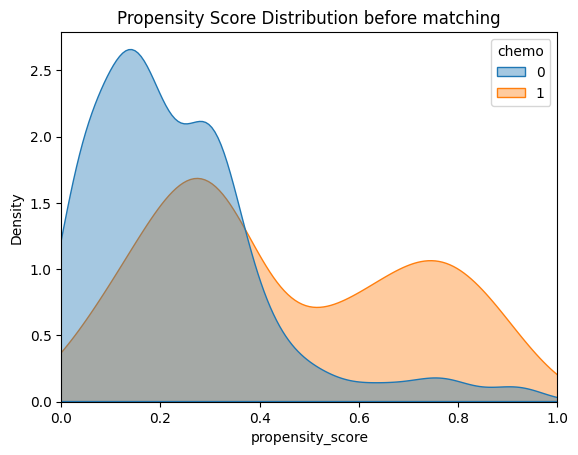

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(
    data=df_combined,
    x="propensity_score",
    hue="chemo",
    common_norm=False,
    fill=True,
    alpha=0.4
)
plt.xlim(0, 1)  
plt.title("Propensity Score Distribution before matching")
plt.show()

#### 1 to 2 Matching based on propensity scores (2 control unit to each treated unit)

In [16]:
from R4R_tools.matching import control_matching

matching_ratio = 1
df_matched = control_matching(df_combined, treatment_col="chemo", score_cols=["propensity_score"], ratio=matching_ratio)
df_matched["chemo"].value_counts() # size of treatment and control arm

chemo
1    188
0    188
Name: count, dtype: int64

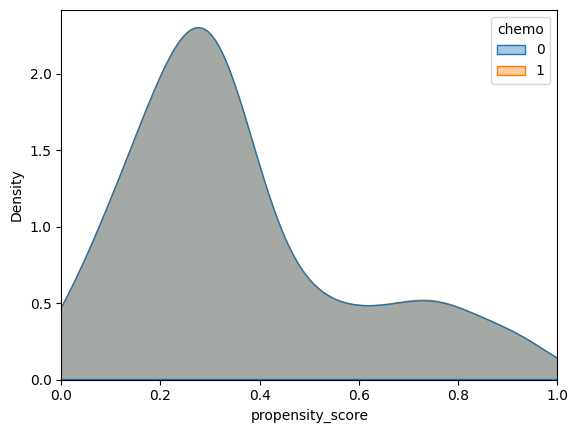

In [10]:
sns.kdeplot(
    data=df_matched,
    x="propensity_score",
    hue="chemo",
    common_norm=False,
    fill=True,
    alpha=0.4
)
plt.xlim(0, 1)  
plt.show()

In [17]:
df_matched.drop(columns = ["propensity_score"], inplace=True)
df_matched.to_csv(f"../data/matched_cohort_1to{matching_ratio}.csv", index = False)

#### We could compare covariate distribution before and after matching